In [3]:
import os
import pysam
import numpy as np
import pandas as pd
from collections import defaultdict

# 1. Define Paths (Using your clean Linux structure)
BASE_DIR = os.path.expanduser('~/celltor')
RAW_DATA_DIR = os.path.join(BASE_DIR, 'data', 'raw')

VCF_PATH = os.path.join(RAW_DATA_DIR, 'ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz')
PANEL_PATH = os.path.join(RAW_DATA_DIR, 'integrated_call_samples_v3.20130502.ALL.panel')

# 2. Population Mapping (Strictly following your project specs)
afr_subs = {'YRI', 'LWK', 'GWD', 'MSL', 'ESN', 'ACB', 'ASW'}
eur_subs = {'CEU', 'TSI', 'FIN', 'GBR', 'IBS'}

# Load the panel file
panel_df = pd.read_csv(PANEL_PATH, sep='\t', usecols=['sample', 'pop'])

# Create a dictionary mapping sample ID -> Super Population (AFR or EUR)
sample_to_pop = {}
for _, row in panel_df.iterrows():
    if row['pop'] in afr_subs:
        sample_to_pop[row['sample']] = 'AFR'
    elif row['pop'] in eur_subs:
        sample_to_pop[row['sample']] = 'EUR'

print(f"Total AFR/EUR samples found in panel: {len(sample_to_pop)}")

Total AFR/EUR samples found in panel: 1164


In [4]:
# 3. Parse the VCF File safely (Extracting 1000 SNPs for the baseline)
MAX_SNPS = 1000
snps_extracted = 0

# Using a standard dict to strictly enforce column creation
genotype_data = {
    'sample': [],
    'pop': []
}

print("Opening VCF and extracting SNPs. Give it a few seconds...")
vcf_in = pysam.VariantFile(VCF_PATH)

# Get all sample IDs present in the VCF
vcf_samples = list(vcf_in.header.samples)

# Filter our mapping to only include samples actually present in the VCF
valid_samples = [s for s in vcf_samples if s in sample_to_pop]
print(f"Valid AFR/EUR samples in VCF: {len(valid_samples)}")

# Initialize the metadata columns
for sample in valid_samples:
    genotype_data['sample'].append(sample)
    genotype_data['pop'].append(sample_to_pop[sample])

# Iterate through the VCF records (rows = SNPs)
for record in vcf_in.fetch():
    if snps_extracted >= MAX_SNPS:
        break
    
    # Filter: must have alternate alleles, and strictly biallelic
    if record.alts and len(record.alts) == 1:
        # FIX: Make the column name strictly unique
        snp_name = f"{record.chrom}_{record.pos}_{record.ref}_{record.alts[0]}"
        
        # Skip if somehow we still hit an exact duplicate
        if snp_name in genotype_data:
            continue
            
        genotype_data[snp_name] = []
        
        # Extract genotype for our valid samples
        for sample in valid_samples:
            gt = record.samples[sample]['GT'] 
            
            # Impute missing as homozygous reference (0)
            if gt[0] is None or gt[1] is None:
                gt_val = 0 
            else:
                gt_val = sum(gt)
                
            genotype_data[snp_name].append(gt_val)
            
        snps_extracted += 1

vcf_in.close()

# Convert to a Pandas DataFrame
df = pd.DataFrame(genotype_data)
print(f"\nExtraction complete!")
print(f"Dataset shape: {df.shape} (Samples x [Metadata + {MAX_SNPS} SNPs])")
print("\nClass Distribution:")
print(df['pop'].value_counts())
display(df.head())

Opening VCF and extracting SNPs. Give it a few seconds...
Valid AFR/EUR samples in VCF: 1164

Extraction complete!
Dataset shape: (1164, 1002) (Samples x [Metadata + 1000 SNPs])

Class Distribution:
pop
AFR    661
EUR    503
Name: count, dtype: int64


,sample,pop,22_16050075_A_G,22_16050115_G_A,22_16050213_C_T,22_16050319_C_T,22_16050527_C_A,22_16050568_C_A,22_16050607_G_A,22_16050627_G_T,...,22_16139876_C_T,22_16139887_A_T,22_16139971_A_G,22_16139996_G_T,22_16140054_G_A,22_16140116_A_T,22_16140141_A_T,22_16140164_C_G,22_16140171_A_C,22_16140320_C_A
0,HG00096,EUR,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,HG00097,EUR,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,HG00099,EUR,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,HG00100,EUR,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,HG00101,EUR,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

X = df.drop(columns=['sample', 'pop'])
y_raw = df['pop']

le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f"Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

print("\nTraining Logistic Regression Baseline...")
lr_model = LogisticRegression(max_iter=3000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
recall_per_class = cm.diagonal() / cm.sum(axis=1)

tpr_afr = recall_per_class[le.transform(['AFR'])[0]]
tpr_eur = recall_per_class[le.transform(['EUR'])[0]]
tpr_gap = abs(tpr_afr - tpr_eur)

print("\n--- BASELINE RESULTS ---")
print(f"Accuracy:  {acc:.4f}")
print(f"TPR AFR:   {tpr_afr:.4f}")
print(f"TPR EUR:   {tpr_eur:.4f}")
print(f"TPR Gap:   {tpr_gap:.4f}")

Class mapping: {'AFR': np.int64(0), 'EUR': np.int64(1)}
Training set shape: (931, 1000)
Testing set shape: (233, 1000)

Training Logistic Regression Baseline...

--- BASELINE RESULTS ---
Accuracy:  0.9356
TPR AFR:   0.9242
TPR EUR:   0.9505
TPR Gap:   0.0263


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# 1. RANDOM FOREST BASELINE
# ==========================================
print("Training Random Forest Baseline...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_pred)

rf_cm = confusion_matrix(y_test, rf_pred)
rf_recall = rf_cm.diagonal() / rf_cm.sum(axis=1)
rf_tpr_gap = abs(rf_recall[0] - rf_recall[1]) # 0=AFR, 1=EUR

print("\n--- RANDOM FOREST RESULTS ---")
print(f"Accuracy:  {rf_acc:.4f}")
print(f"TPR Gap:   {rf_tpr_gap:.4f}")

# ==========================================
# 2. 1D CNN BASELINE (PyTorch)
# ==========================================
print("\nPreparing PyTorch tensors for 1D CNN...")

# Convert numpy arrays to PyTorch tensors (Shape: Batch, Channels, Length)
# CNN expects 3D input: (N_samples, 1_channel, 1000_SNPs)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define the exact CNN architecture from your project specs
class GenomicCNN(nn.Module):
    def __init__(self, input_length=1000):
        super(GenomicCNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2), # Halves the spatial dimension (1000 -> 500)
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        # Calculate flattened size: 500 length * 64 channels
        flattened_size = (input_length // 2) * 64
        
        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.fc_block(x)
        return x

# Initialize Model, Loss, and Optimizer
device = torch.device("cpu") # Forcing CPU for maximum stability in WSL
cnn_model = GenomicCNN(input_length=X_train_scaled.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

print("Training 1D CNN for 10 Epochs...")
cnn_model.train()
for epoch in range(10):
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = cnn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/10], Loss: {total_loss/len(train_loader):.4f}")

# Evaluate CNN
cnn_model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = cnn_model(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(batch_y.numpy())

cnn_acc = accuracy_score(all_targets, all_preds)
cnn_cm = confusion_matrix(all_targets, all_preds)
cnn_recall = cnn_cm.diagonal() / cnn_cm.sum(axis=1)
cnn_tpr_gap = abs(cnn_recall[0] - cnn_recall[1])

print("\n--- 1D CNN RESULTS ---")
print(f"Accuracy:  {cnn_acc:.4f}")
print(f"TPR Gap:   {cnn_tpr_gap:.4f}")

Training Random Forest Baseline...

--- RANDOM FOREST RESULTS ---
Accuracy:  0.9099
TPR Gap:   0.0018

Preparing PyTorch tensors for 1D CNN...
Training 1D CNN for 10 Epochs...
Epoch [5/10], Loss: 0.0356
Epoch [10/10], Loss: 0.0100

--- 1D CNN RESULTS ---
Accuracy:  0.9099
TPR Gap:   0.0332


Starting Imbalance Simulation. This will take a minute or two...

--- Simulating Training with 100% AFR Data ---
--- Simulating Training with 50% AFR Data ---
--- Simulating Training with 30% AFR Data ---
--- Simulating Training with 20% AFR Data ---
--- Simulating Training with 10% AFR Data ---

Simulation Complete! Plotting Fairness Degradation...


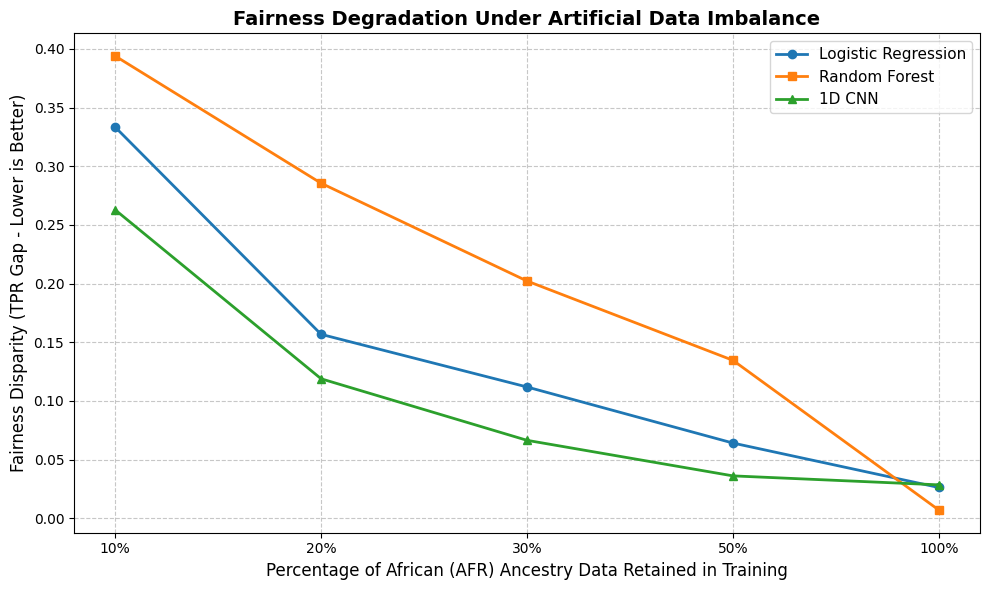

In [7]:
import matplotlib.pyplot as plt
import copy
import numpy as np

# Retention rates for the AFR class (1.0 = 100%, 0.5 = 50%, etc.)
retention_rates = [1.0, 0.5, 0.3, 0.2, 0.1]

# Dictionaries to store the TPR Gaps for plotting
tpr_results = {
    'Logistic Regression': [],
    'Random Forest': [],
    '1D CNN': []
}

# Identify the AFR indices in the training set (AFR was encoded as 0)
afr_indices = np.where(y_train == 0)[0]
eur_indices = np.where(y_train == 1)[0]

print("Starting Imbalance Simulation. This will take a minute or two...\n")

for rate in retention_rates:
    print(f"--- Simulating Training with {int(rate*100)}% AFR Data ---")
    
    # Calculate how many AFR samples to keep
    n_keep = int(len(afr_indices) * rate)
    
    # Randomly select the subset of AFR indices
    np.random.seed(42) # Keep it reproducible
    kept_afr_indices = np.random.choice(afr_indices, n_keep, replace=False)
    
    # Combine the kept AFR samples with all the EUR samples
    skewed_train_indices = np.concatenate([kept_afr_indices, eur_indices])
    np.random.shuffle(skewed_train_indices) # Shuffle the new skewed dataset
    
    # Create the skewed training sets
    X_train_skewed = X_train_scaled[skewed_train_indices]
    y_train_skewed = y_train[skewed_train_indices]
    
    # -------------------------------------------------
    # 1. Train & Evaluate Logistic Regression
    # -------------------------------------------------
    lr = LogisticRegression(max_iter=3000, random_state=42)
    lr.fit(X_train_skewed, y_train_skewed)
    lr_cm = confusion_matrix(y_test, lr.predict(X_test_scaled))
    lr_recall = lr_cm.diagonal() / lr_cm.sum(axis=1)
    tpr_results['Logistic Regression'].append(abs(lr_recall[0] - lr_recall[1]))

    # -------------------------------------------------
    # 2. Train & Evaluate Random Forest
    # -------------------------------------------------
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train_skewed, y_train_skewed)
    rf_cm = confusion_matrix(y_test, rf.predict(X_test_scaled))
    rf_recall = rf_cm.diagonal() / rf_cm.sum(axis=1)
    tpr_results['Random Forest'].append(abs(rf_recall[0] - rf_recall[1]))

    # -------------------------------------------------
    # 3. Train & Evaluate 1D CNN
    # -------------------------------------------------
    # Prepare PyTorch datasets for the skewed data
    X_skewed_tensor = torch.tensor(X_train_skewed, dtype=torch.float32).unsqueeze(1)
    y_skewed_tensor = torch.tensor(y_train_skewed, dtype=torch.long)
    skewed_loader = DataLoader(TensorDataset(X_skewed_tensor, y_skewed_tensor), batch_size=32, shuffle=True)
    
    # Re-initialize a fresh CNN model so it doesn't remember the previous runs
    cnn = GenomicCNN(input_length=X_train_skewed.shape[1]).to(device)
    optimizer = optim.Adam(cnn.parameters(), lr=0.001)
    
    cnn.train()
    for epoch in range(10):
        for batch_X, batch_y in skewed_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(cnn(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            
    # Evaluate CNN
    cnn.eval()
    all_preds = []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            outputs = cnn(batch_X.to(device))
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            
    cnn_cm = confusion_matrix(y_test, all_preds)
    cnn_recall = cnn_cm.diagonal() / cnn_cm.sum(axis=1)
    tpr_results['1D CNN'].append(abs(cnn_recall[0] - cnn_recall[1]))

print("\nSimulation Complete! Plotting Fairness Degradation...")

# ==========================================
# 4. PLOT THE RESULTS
# ==========================================
plt.figure(figsize=(10, 6))

x_labels = [f"{int(r*100)}%" for r in retention_rates]

plt.plot(x_labels, tpr_results['Logistic Regression'], marker='o', label='Logistic Regression', linewidth=2)
plt.plot(x_labels, tpr_results['Random Forest'], marker='s', label='Random Forest', linewidth=2)
plt.plot(x_labels, tpr_results['1D CNN'], marker='^', label='1D CNN', linewidth=2)

plt.title("Fairness Degradation Under Artificial Data Imbalance", fontsize=14, fontweight='bold')
plt.xlabel("Percentage of African (AFR) Ancestry Data Retained in Training", fontsize=12)
plt.ylabel("Fairness Disparity (TPR Gap - Lower is Better)", fontsize=12)
plt.gca().invert_xaxis() # Invert x-axis so it goes from 100% down to 10%
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()